In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
from lib.Forecast.SimpleTransformerForecast import SimpleTransformerForecast
from lib.Forecast.PatchTransformerForecast import PatchTransformerForecast, PatchTransformerForecast2
from lib.Forecast.PatchTransformerExoForecast import PatchTransformerExoForecast
from lib.Dataloaders.ECGDataset import ECGDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Function to train the model
def train_loop(model,
               train,
               val,
               optimizer,
               scheduler=None,
               patience=5,
               epochs=100,
               exogenous=False,
               conditional=False,
               lossf=F.mse_loss):
    """_Training loop for the model_

    Args:
        model: model to train
        optimizer: pytorch optimizer, for example torch.optim.Adam
        train: training data
        val: validation data
        epochs: number of epochs

    Returns:
        _type_: training history, a dictionary with the training and validation loss for each epoch
    """

    def epoch_loss(dataset, conditional=conditional, exogenous=exogenous):
        data_loss = 0.0
        for i, data in enumerate(dataset):
            # if conditional:
            #     lookback_data, horizon_data, cond_data = data
            #     cond_data = cond_data.to('cuda')
            # else:
            #     lookback_data, horizon_data = data
            #     cond_data = None
            # lookback_data = lookback_data.to('cuda')
            # horizon_data = horizon_data.to('cuda')
            # Indipendentemente da 'conditional', estraiamo sempre e solo 2 valori
            # perché sappiamo che il nostro ECGDataset restituisce solo (X, y)
            lookback_data, horizon_data = data
            lookback_data = lookback_data.to('cuda')
            horizon_data = horizon_data.to('cuda')
            
            # Generazione DUMMY dei dati condizionali (Stress Test Mode)
            if conditional:
                # Creiamo un tensore "fantoccio" per i dati condizionali. 
                # Cloniamo il lookback e assicuriamoci che abbia la dimensione giusta.
                # NUOVA RIGA CORRETTA
                # Prendiamo solo l'ultimo istante temporale per avere la forma (Batch, 8)
                cond_data = lookback_data[:, :, -1].clone() if conditional else None
            else:
                cond_data = None
            # We do not have the exogenous data in the dataset, so we will use the lookback data as exogenous data
            if exogenous:
                exogenous_data = lookback_data.clone()
            exogenous_data = exogenous_data.to('cuda') if exogenous else None
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')
            outputs = model(inputs,
                            exo=exogenous_data if exogenous else None,
                            cond=cond_data if conditional else None).squeeze()

            loss = lossf(y, outputs)
            data_loss += loss.item()
        return data_loss / (i + 1)

    def early_stopping(val_loss, patience=5):
        if len(val_loss) > patience:
            if val_loss[-1] > np.mean(val_loss[-(patience + 1):-1]):
                return True

    hist_loss = {'train': [], 'val': []}
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # loop for all the epochs
        # print(f"Epoch {epoch + 1}/{epochs}")
        for i, data in enumerate(train):
            # if conditional:
            #     lookback_data, horizon_data, cond_data = data
            #     cond_data = cond_data.to('cuda')
            # else:
            #     lookback_data, horizon_data = data
            #     cond_data = None
            # lookback_data = lookback_data.to('cuda')
            # horizon_data = horizon_data.to('cuda')
            # 1. ESTRAZIONE SICURA A 2 VALORI (Qui c'era il tuo errore!)
            lookback_data, horizon_data = data
            lookback_data = lookback_data.to('cuda')
            horizon_data = horizon_data.to('cuda')

            # 2. GENERAZIONE DUMMY DATA CONDIZIONALE ed ESOGENO# NUOVA RIGA CORRETTA
            # Prendiamo solo l'ultimo istante temporale per avere la forma (Batch, 8)
            cond_data = lookback_data[:, :, -1].clone() if conditional else None
            # We do not have the exogenous data in the dataset, so we will use the lookback data as exogenous data
            if exogenous:
                exogenous_data = lookback_data.clone()
            exogenous_data = exogenous_data.to('cuda') if exogenous else None

            # take the data and upload it to the GPU
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')

            # Reset the gradients
            optimizer.zero_grad()

            # Apply the data to the model
            outputs = model(inputs,
                            exo=exogenous_data if exogenous else None,
                            cond=cond_data if conditional else None).squeeze()
            # Calculate the loss
            loss = lossf(y, outputs)

            # Make the backward pass
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Calculate the loss in the training and validation sets
        with torch.no_grad():
            hist_loss['train'].append(
                epoch_loss(train, conditional=conditional,
                           exogenous=exogenous))
            hist_loss['val'].append(
                epoch_loss(val, conditional=conditional, exogenous=exogenous))

        # Show the loss in the training and validation sets
        pbar.set_postfix({
            'train': hist_loss['train'][-1],
            'val': hist_loss['val'][-1],
            'lr': optimizer.param_groups[0]['lr']
        })

        # If the loss in the validation set does not decrease, stop the training
        if early_stopping(hist_loss['val'], patience):
            print("\nEarly stopping innescato!")
            break

    return hist_loss

In [3]:
# def plot_prediction(model, data, channel=0):
#     X, y = data

#     pred = model(torch.tensor(X).unsqueeze(0).to('cuda'),
#                  exo=None,
#                  cond=None).squeeze().cpu().detach().numpy()

#     plt.figure(figsize=(12, 6))
#     ax = plt.subplot(1, 2, 1)
#     plt.plot(X[channel], label='lookback')
#     mx, mn = np.max(X[channel]), np.min(X[channel])
#     plt.legend()
#     ax = plt.subplot(1, 2, 2)
#     plt.plot(y, label='true')
#     plt.plot(pred, label='pred')
#     #plt.ylim(mn , mx )
#     plt.legend()
# %%
def plot_prediction(model, data, channel=0, conditional=True, exogenous=True):
    X, y = data
    
    # 1. Prepariamo il tensore di input principale
    inputs = torch.tensor(X).unsqueeze(0).to('cuda')
    
    # 2. Generiamo i dati fittizi esattamente come nel train_loop
    cond_data = inputs[:, :, -1].clone() if conditional else None
    exo_data = inputs.clone() if exogenous else None

    # 3. Facciamo la predizione passando TUTTI E TRE gli input
    pred = model(inputs, exo=exo_data, cond=cond_data).squeeze().cpu().detach().numpy()

    plt.figure(figsize=(12, 6))
    ax = plt.subplot(1, 2, 1)
    plt.plot(X[channel], label='lookback')
    mx, mn = np.max(X[channel]), np.min(X[channel])
    plt.legend()
    ax = plt.subplot(1, 2, 2)
    plt.plot(y, label='true')
    plt.plot(pred, label='pred')
    #plt.ylim(mn , mx )
    plt.legend()

In [4]:
lookback = 100
horizon = 25
batch_size = 2048
stride = 10
norm = "zscore"
norm_all = False
samples = (2500, 200, 200)
channel = 0
labels = True

In [5]:
train = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='train',
                   nsamples=samples[0],
                   channel=channel,
                   norm=norm,
                   norm_all=norm_all,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride,
                   labels=labels)
val = ECGDataset(dir='../Preprocess/PTBXL',
                 dataset='validation',
                 nsamples=samples[1],
                 channel=channel,
                 norm=norm,
                 norm_all=norm_all,
                 lookback=lookback,
                 horizon=horizon,
                 stride=stride,
                 labels=labels)
test = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='test',
                   nsamples=samples[2],
                   channel=channel,
                   norm=norm,
                   norm_all=norm_all,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride,
                   labels=labels)
train = DataLoader(train, batch_size=batch_size, shuffle=True)
val = DataLoader(val, batch_size=batch_size, shuffle=False)
test = DataLoader(test, batch_size=batch_size, shuffle=False)

Loading data from ../Preprocess/PTBXL
train
X_train shape is (220000, 8, 100)
y_train shape is (220000, 25)
dlabels shape is (88,)
NORM=zscore
Loading data from ../Preprocess/PTBXL
validation
X_train shape is (17600, 8, 100)
y_train shape is (17600, 25)
dlabels shape is (88,)
NORM=zscore
Loading data from ../Preprocess/PTBXL
test
X_train shape is (17600, 8, 100)
y_train shape is (17600, 25)
dlabels shape is (88,)
NORM=zscore


In [6]:
# model = SimpleTransformerForecast(lookback=lookback,
#                                   horizon=horizon,
#                                   input_dim=8,
#                                   target_dim=1,
#                                   d_model=16,
#                                   n_heads=2,
#                                   num_layers=6, dropout=0).to('cuda')
# model.compile()

In [7]:
# model = PatchTransformerForecast(lookback=lookback,
#                                 horizon=horizon,
#                                 input_dim=8,
#                                 target_dim=1,
#                                 d_model=64,
#                                 n_heads=8,
#                                 num_layers=2, dropout=0, patch_len=10).to('cuda')

In [8]:
# model = PatchTransformerForecast2(lookback=lookback,
#                                   horizon=horizon,
#                                   input_dim=8,
#                                   target_dim=1,
#                                   d_model=64,
#                                   n_heads=8,
#                                   num_layers=2,
#                                   norm_first=True,
#                                   dropout=0,
#                                   patch_len=10,
#                                   layer_norm_eps=1e-5,
#                                   bias=True,
#                                   swiglu=True,
#                                   rmsnorm=True,
#                                   trans_norm=True,
#                                   device='cuda').to('cuda')
# model.compile()

In [9]:
model = PatchTransformerExoForecast(lookback=lookback,
                                  horizon=horizon,
                                  input_dim=8,
                                  target_dim=1,
                                  condition_dim=8,
                                  d_model=64,
                                  n_heads=8,
                                  num_layers=2,
                                  norm_first=True,
                                  dropout=0,
                                  patch_len=10,
                                  layer_norm_eps=1e-5,
                                  bias=True,
                                  swiglu=True,
                                  rmsnorm=True,
                                  trans_norm=True,
                                  device='cuda', verbose=False).to('cuda')
# model.compile()

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=20, gamma=0.90)

In [11]:
# # Testing the model with random input
# random_input = torch.randn(32, 8, 120).to('cuda')
# model.to('cuda')
# model(random_input).shape

In [12]:
hist_loss = train_loop(model, train, val, optimizer, scheduler, epochs=1000, patience=100, exogenous=True, conditional=True)

  0%|          | 0/1000 [00:00<?, ?it/s]


Early stopping innescato!


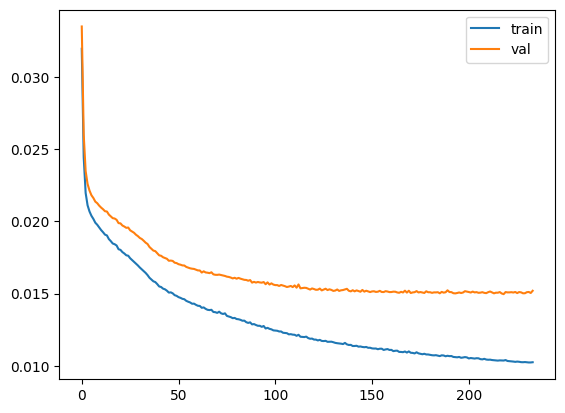

In [13]:
plt.plot(hist_loss['train'], label='train')
plt.plot(hist_loss['val'], label='val')
plt.legend()


In [14]:
print(scheduler.get_last_lr())

[3.138105960900002e-05]


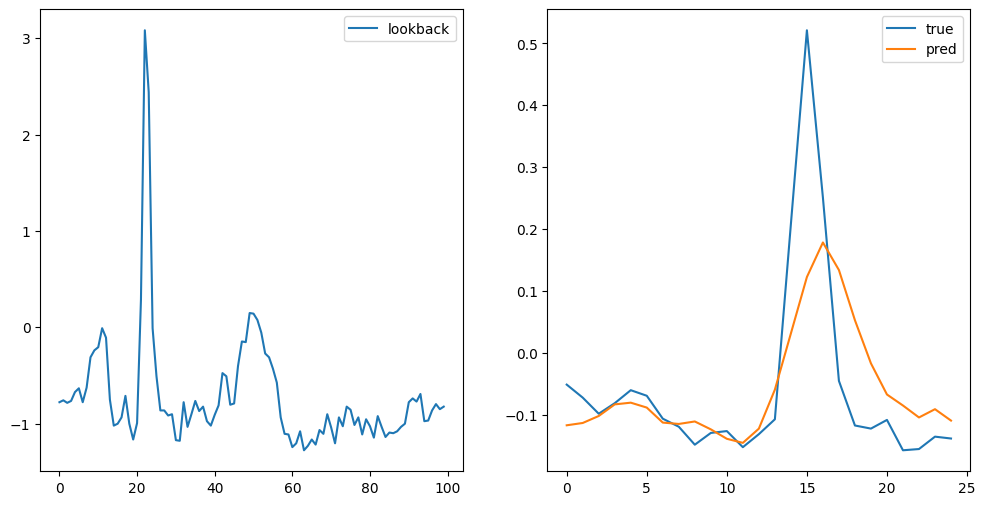

In [15]:
plot_prediction(model, train.dataset[0])

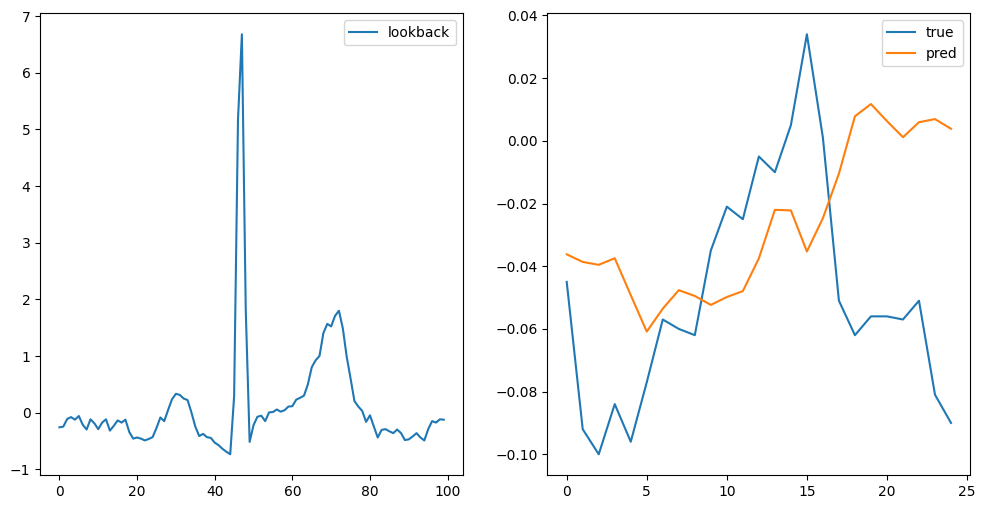

In [16]:
plot_prediction(model, val.dataset[0])

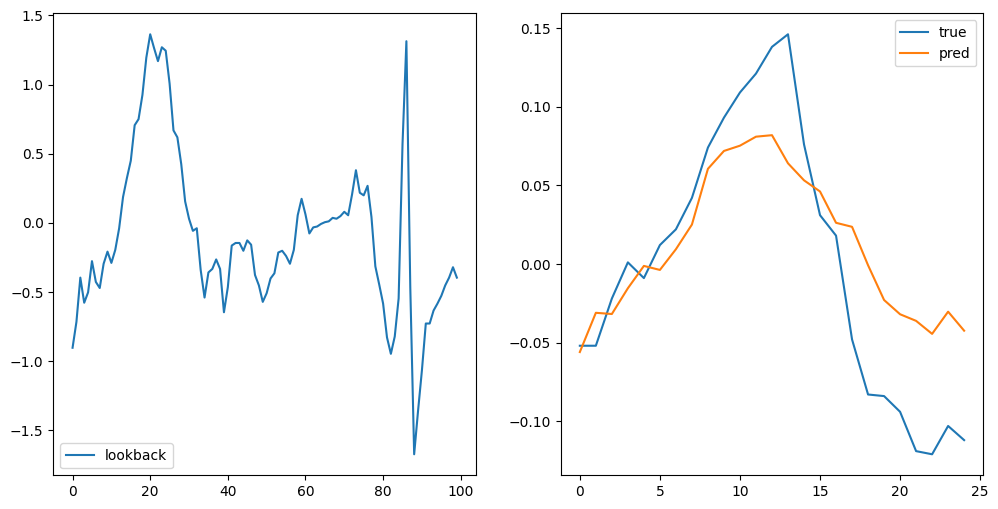

In [17]:
plot_prediction(model, test.dataset[0])

In [18]:
# def dataset_loss(dataset):
#     data_loss = 0.0
#     for i, (lookback_data, horizon_data) in enumerate(dataset):
#         inputs = lookback_data.to('cuda')
#         y = horizon_data.to('cuda')
#         outputs = model(inputs).squeeze()
#         loss = F.mse_loss(y, outputs)
#         data_loss += loss.item()
#     return data_loss / (i + 1)
# print('Train loss:', dataset_loss(train))
# print('Val loss:', dataset_loss(val))
# print('Test loss:', dataset_loss(test))
# %%
def dataset_loss(dataset, conditional=True, exogenous=True):
    data_loss = 0.0
    for i, (lookback_data, horizon_data) in enumerate(dataset):
        inputs = lookback_data.to('cuda')
        y = horizon_data.to('cuda')
        
        # 1. Generiamo i dati fittizi
        cond_data = inputs[:, :, -1].clone() if conditional else None
        exo_data = inputs.clone() if exogenous else None
        
        # 2. Passiamo tutto al modello
        outputs = model(inputs, exo=exo_data, cond=cond_data).squeeze()
        
        loss = F.mse_loss(y, outputs)
        data_loss += loss.item()
        
    return data_loss / (i + 1)

print('Train loss:', dataset_loss(train))
print('Val loss:', dataset_loss(val))
print('Test loss:', dataset_loss(test))

Train loss: 0.010249412972135124
Val loss: 0.015195391865240203
Test loss: 0.014636097475886345


In [19]:
# Dopo che l'addestramento è finito e sei soddisfatto
percorso_salvataggio = 'weights_transformer_patch.pth'

# Salviamo SOLO lo state_dict (i pesi)
torch.save(model.state_dict(), percorso_salvataggio)
print(f"[*] Pesi salvati correttamente in: {percorso_salvataggio}")

[*] Pesi salvati correttamente in: weights_transformer_patch.pth


In [23]:
# 3. Generazione della tabella passandogli il modello e la forma esatta dell'input
# La forma dell'input per il PatchTransformer deve essere (Batch, Canali, Tempo) -> (1, 8, 100)
from torchinfo import summary

summary(model, input_data=(
    torch.randn(1, 8, 100).cuda(),
    None,
    None
))
print(model)

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Conv1d: 1]